<a href="https://colab.research.google.com/github/Rems-dev1/lab-3-feedforward-networks/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Starting
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Part 1.1 — A single neuron is just a line

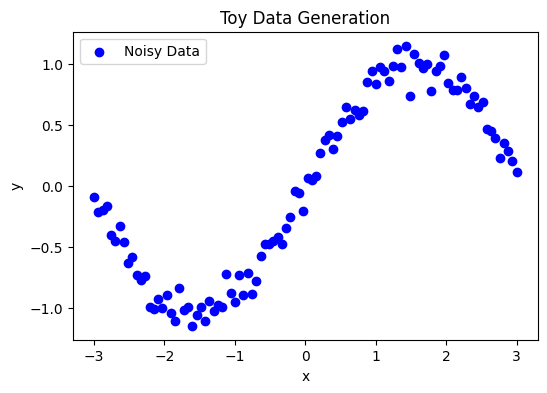

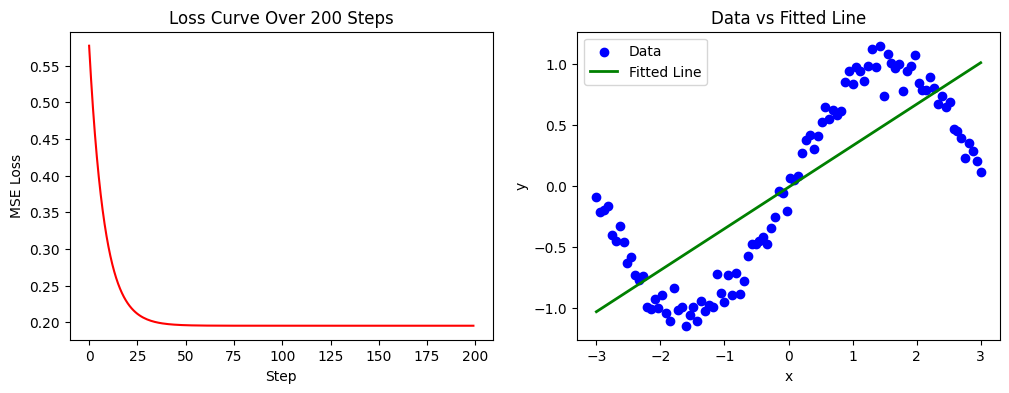

In [3]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, 100)
y = np.sin(x) + noise

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Noisy Data')
plt.title('Toy Data Generation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.01
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
for step in range(200):
    y_hat = w * x + b

    # mse
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #  calculat gradient
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # update weights and bias using learning rate
    w = w - lr * dw
    b = b - lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(12, 4))

# Plot (a) Loss Curve
plt.subplot(1, 2, 1)
plt.plot(losses, color='red')
plt.title('Loss Curve Over 200 Steps')
plt.xlabel('Step')
plt.ylabel('MSE Loss')

# Plot (b) Fitted Line
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, w * x + b, color='green', linewidth=2, label='Fitted Line')
plt.title('Data vs Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**Student Reasoning — The single neuron**

The loss function is

$$
\text{Loss}=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2.
$$

Where the y  with hat is:

$$
\hat{y}_i=wx_i+b.
$$

Substituting that y_hat into the loss function:

$$
\text{Loss}=\frac{1}{N}\sum_{i=1}^{N}(wx_i+b-y_i)^2.
$$

taking the partial derivative with respect to \(w\).

Using the chain rule,

$$
\frac{\partial}{\partial w}(u^2)=2u\frac{\partial u}{\partial w},
$$

where

$$
u=wx_i+b-y_i.
$$

Since xi, b, and yi are constants with respect to w, their derivative will be:

$$
\frac{\partial}{\partial w}(wx_i+b-y_i)=x_i.
$$


Therefore,

$$
\frac{\partial \text{Loss}}{\partial w}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(wx_i+b-y_i)x_i.
$$

Since

$$
\hat{y}_i=wx_i+b,
$$

the equation can also be written as

$$
\frac{\partial \text{Loss}}{\partial w}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(\hat{y}_i-y_i)x_i.
$$

taking the partial derivative with respect to \(b\).

The derivative of the inside term is

$$
\frac{\partial}{\partial b}(wx_i+b-y_i)=1.
$$

So,

$$
\frac{\partial \text{Loss}}{\partial b}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(\hat{y}_i-y_i).
$$

These equations match the code because `np.mean()` calculates the average over all data points.


This is underfitting because the model is too simple to fit the data. A single neuron uses the equation y=wx+b, so it can only draw a straight line. A sine wave is a curved line that goes up and down. Because of this, a straight line cannot match the sine wave well. Even if we train the model for a longer time, it still cannot fit the sine wave because the model is too simple.


**Part 1.2 — Hidden layers and activations: why depth helps**

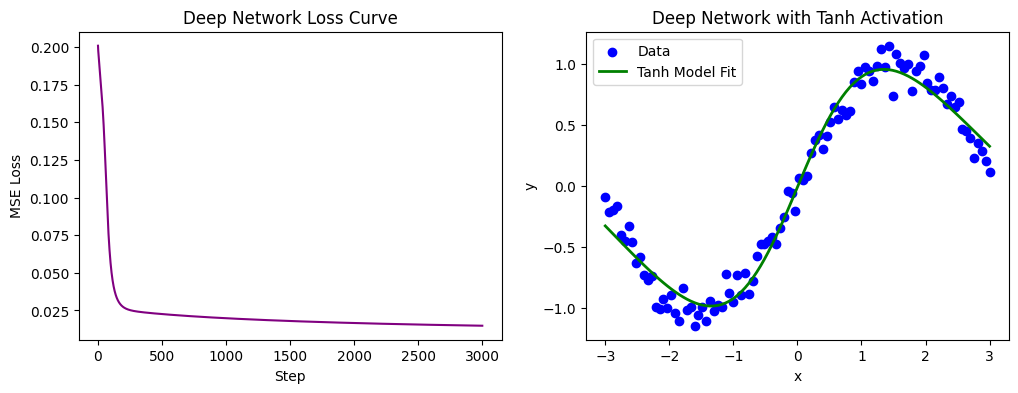

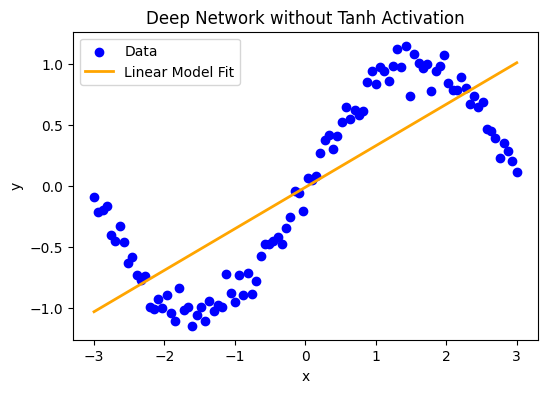

In [4]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1,))

# Reshape input data arrays to matrices for matrix multiplication
x_matrix = x.reshape(-1, 1)
y_matrix = y.reshape(-1, 1)

lr = 0.05
losses_deep = []

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
for step in range(3000):
    # TODO: Forward pass (keep the intermediate values — you need them for backprop):
    #   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    #   h  = np.tanh(z1)        # activation
    #   y_hat = h @ W2 + b2     # output, shape (100, 1)
    #   loss  = np.mean((y_hat - y) ** 2)
    z1 = x_matrix @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_matrix) ** 2)
    losses_deep.append(loss)

    # TODO: Backward pass (the chain rule, layer by layer):
    #   d_yhat = 2 * (y_hat - y) / len(y)
    #   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    #   dh  = d_yhat @ W2.T
    #   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    #   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
    N = len(y_matrix)
    d_yhat = 2 * (y_hat - y_matrix) / N
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_matrix.T @ dz1
    db1 = dz1.sum(axis=0)

    # Param updates
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_deep, color='purple')
plt.title('Deep Network Loss Curve')
plt.xlabel('Step')
plt.ylabel('MSE Loss')

plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_hat, color='green', linewidth=2, label='Tanh Model Fit')
plt.title('Deep Network with Tanh Activation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Re-running the experiment with Tanh removed
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros((8,))
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros((1,))
losses_linear = []

for step in range(3000):
    z1_lin = x_matrix @ W1_lin + b1_lin
    h_lin = z1_lin # Tanh activation function is removed here
    y_hat_lin = h_lin @ W2_lin + b2_lin

    loss_lin = np.mean((y_hat_lin - y_matrix) ** 2)
    losses_linear.append(loss_lin)

    d_yhat_lin = 2 * (y_hat_lin - y_matrix) / len(y_matrix)
    dW2_lin = h_lin.T @ d_yhat_lin
    db2_lin = d_yhat_lin.sum(axis=0)

    dh_lin = d_yhat_lin @ W2_lin.T
    dz1_lin = dh_lin * 1.0  # derivative of a linear activation is 1
    dW1_lin = x_matrix.T @ dz1_lin
    db1_lin = dz1_lin.sum(axis=0)

    W1_lin = W1_lin - lr * dW1_lin
    b1_lin = b1_lin - lr * db1_lin
    W2_lin = W2_lin - lr * dW2_lin
    b2_lin = b2_lin - lr * db2_lin

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_hat_lin, color='orange', linewidth=2, label='Linear Model Fit')
plt.title('Deep Network without Tanh Activation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**

1.**With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.**
- If the `tanh` activation is removed, the network only uses linear calculations.

$$
y = (x \cdot W_1 + b_1) \cdot W_2 + b_2
$$

This can be simplified to

$$
y = x \cdot W_{new} + b_{new},
$$

where

$$
W_{new} = W_1 \cdot W_2
$$

and

$$
b_{new} = b_1 \cdot W_2 + b_2.
$$

- This means the whole network becomes just one linear model. Even though there are 8 hidden neurons, the network can still only learn a straight line. Because of this, it cannot fit the curved sine wave well.

2.**What role did the hidden layer's 8 neurons play in fitting the curve?**

- The 8 hidden neurons each learn a different part of the pattern. After the `tanh` activation, each neuron produces a different curved output. The output layer combines these curves to make a shape that is close to the sine wave.

3.**This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?**

- Backpropagation is the process of sending the error from the output layer back through the network. It uses the chain rule to calculate how each weight affects the error , so the weights can be updated and the model can learn.